## 1. IMPORT & DEFINE CLASS

In [2]:
import os
import json
import random
from pathlib import Path

from PIL import Image


class CAMOFS:
    """
    Simple CAMO-FS dataset loader for COCO-format annotations.
    """

    def __init__(self, root: str, ann_file: str):
        self.root = root
        self.ann_file = ann_file

        with open(ann_file, "r", encoding="utf-8") as f:
            self.coco = json.load(f)

        self.images = {
            img["id"]: img
            for img in self.coco["images"]
        }

        self.annotations_by_image = {}

        for ann in self.coco["annotations"]:
            image_id = ann["image_id"]

            if image_id not in self.annotations_by_image:
                self.annotations_by_image[image_id] = []

            self.annotations_by_image[image_id].append(ann)

        self.ids = sorted(self.images.keys())

    def _load_image(self, image_id: int):
        file_name = self.images[image_id]["file_name"]
        image_path = os.path.join(self.root, file_name)

        return Image.open(image_path).convert("RGB")

    def _load_target(self, image_id: int):
        return self.annotations_by_image.get(image_id, [])

    def __getitem__(self, index: int):
        image_id = self.ids[index]

        image = self._load_image(image_id)
        target = self._load_target(image_id)

        return image, target

    def __len__(self):
        return len(self.ids)

## 2. LOAD DATASET

Number of test images: 2655
Image type: <class 'PIL.Image.Image'>
Image size: (276, 183)
Number of instances: 1
Annotation keys: dict_keys(['segmentation', 'area', 'iscrowd', 'image_id', 'bbox', 'category_id', 'id'])

First annotation:
{'segmentation': [[131.0, 137.5, 132.0, 136.5, 136.0, 136.5, 137.0, 135.5, 142.0, 135.5, 142.5, 135.0, 142.5, 134.0, 141.5, 133.0, 141.5, 131.0, 141.0, 130.5, 140.0, 130.5, 139.0, 129.5, 138.0, 129.5, 137.5, 129.0, 138.0, 128.5, 139.0, 128.5, 140.0, 127.5, 141.0, 127.5, 142.0, 126.5, 144.0, 126.5, 145.0, 125.5, 146.0, 125.5, 147.0, 124.5, 148.0, 124.5, 150.0, 122.5, 151.0, 122.5, 152.0, 121.5, 153.0, 121.5, 154.0, 120.5, 155.0, 120.5, 156.0, 119.5, 158.0, 119.5, 159.0, 118.5, 160.0, 118.5, 161.0, 117.5, 163.0, 117.5, 164.0, 116.5, 165.0, 116.5, 166.0, 115.5, 171.0, 115.5, 172.0, 114.5, 173.0, 114.5, 175.0, 112.5, 176.0, 112.5, 178.0, 110.5, 179.0, 110.5, 181.0, 108.5, 182.0, 108.5, 182.5, 108.0, 182.5, 107.0, 183.5, 106.0, 183.5, 105.0, 184.5, 104.0, 184

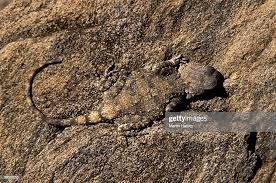

In [3]:
IMAGES_PATH = "data/images"

TEST_ANNOTATIONS_PATH = (
    "data/few-shot-annotations/camo5_test_split1.json"
)

test_dataset = CAMOFS(
    root=IMAGES_PATH,
    ann_file=TEST_ANNOTATIONS_PATH
)

print(f"Number of test images: {len(test_dataset)}")

sample_index = 300

img, target = test_dataset[sample_index]

print(f"Image type: {type(img)}")
print(f"Image size: {img.size}")
print(f"Number of instances: {len(target)}")

if target:
    print(f"Annotation keys: {target[0].keys()}")
    print("\nFirst annotation:")
    print(target[0])

display(img)

## CELL 3 - INSPECT OFFICIAL FEW-SHOT ANNOTATIONS

In [4]:
FEW_SHOT_DIR = Path(
    "data/few-shot-annotations/subsplit/split1"
)

shot_files = {
    1: sorted(FEW_SHOT_DIR.glob("*_1shot_split1.json")),
    2: sorted(FEW_SHOT_DIR.glob("*_2shot_split1.json")),
    3: sorted(FEW_SHOT_DIR.glob("*_3shot_split1.json")),
    5: sorted(FEW_SHOT_DIR.glob("*_5shot_split1.json")),
}

for shot, files in shot_files.items():
    print(f"{shot}-shot: {len(files)} annotation files")

1-shot: 47 annotation files
2-shot: 47 annotation files
3-shot: 47 annotation files
5-shot: 47 annotation files


In [5]:
for shot, files in shot_files.items():

    total_images = set()
    total_annotations = 0

    for file_path in files:

        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        for image in data.get("images", []):
            total_images.add(image["id"])

        total_annotations += len(data.get("annotations", []))

    print(
        f"{shot}-shot | "
        f"unique images: {len(total_images)} | "
        f"annotations: {total_annotations}"
    )

1-shot | unique images: 47 | annotations: 47
2-shot | unique images: 94 | annotations: 94
3-shot | unique images: 141 | annotations: 141
5-shot | unique images: 197 | annotations: 235


## CELL 4 - DEFINE CAMO-FS CATEGORIES


In [6]:
CAMO_CATEGORIES = [
    {'name': 'Frog',          'id': 0,  'color': [220, 20, 60]},
    {'name': 'Crab',          'id': 1,  'color': [119, 11, 32]},
    {'name': 'Dolphin',       'id': 2,  'color': [0, 0, 142]},
    {'name': 'Fish',          'id': 3,  'color': [0, 0, 230]},
    {'name': 'Octopus',       'id': 4,  'color': [106, 0, 228]},
    {'name': 'Seahorse',      'id': 5,  'color': [0, 60, 100]},
    {'name': 'Shrimp',        'id': 6,  'color': [0, 80, 100]},
    {'name': 'Starfish',      'id': 7,  'color': [0, 0, 70]},
    {'name': 'Scorpion',      'id': 8,  'color': [0, 0, 192]},
    {'name': 'Spider',        'id': 9,  'color': [250, 170, 30]},
    {'name': 'Bird',          'id': 10, 'color': [100, 170, 30]},
    {'name': 'Penguin',       'id': 11, 'color': [220, 220, 0]},
    {'name': 'Snail',         'id': 12, 'color': [250, 0, 30]},
    {'name': 'Insect',        'id': 13, 'color': [165, 42, 42]},
    {'name': 'Moth',          'id': 14, 'color': [255, 77, 255]},
    {'name': 'Bat',           'id': 15, 'color': [0, 226, 252]},
    {'name': 'Bear',          'id': 16, 'color': [182, 182, 255]},
    {'name': 'Camel',         'id': 17, 'color': [0, 82, 0]},
    {'name': 'Cat',           'id': 18, 'color': [120, 166, 157]},
    {'name': 'Deer',          'id': 19, 'color': [110, 76, 0]},
    {'name': 'Dog',           'id': 20, 'color': [174, 57, 255]},
    {'name': 'Elephant',      'id': 21, 'color': [199, 100, 0]},
    {'name': 'Fox',           'id': 22, 'color': [72, 0, 118]},
    {'name': 'Giraffe',       'id': 23, 'color': [255, 179, 240]},
    {'name': 'Goat',          'id': 24, 'color': [0, 125, 92]},
    {'name': 'Hedgehog',      'id': 25, 'color': [209, 0, 151]},
    {'name': 'Horse',         'id': 26, 'color': [188, 208, 182]},
    {'name': 'Kangaroo',      'id': 27, 'color': [0, 220, 176]},
    {'name': 'Leopard',       'id': 28, 'color': [255, 99, 164]},
    {'name': 'Lion',          'id': 29, 'color': [92, 0, 73]},
    {'name': 'Monkey',        'id': 30, 'color': [133, 129, 255]},
    {'name': 'Mouse',         'id': 31, 'color': [78, 180, 255]},
    {'name': 'Pig',           'id': 32, 'color': [0, 228, 0]},
    {'name': 'Rabbit',        'id': 33, 'color': [174, 255, 243]},
    {'name': 'Rhino',         'id': 34, 'color': [45, 89, 255]},
    {'name': 'Sea_Lion',      'id': 35, 'color': [134, 134, 103]},
    {'name': 'Sloth',         'id': 36, 'color': [145, 148, 174]},
    {'name': 'Squirrel',      'id': 37, 'color': [197, 226, 255]},
    {'name': 'Tiger',         'id': 38, 'color': [171, 134, 1]},
    {'name': 'Weasel',        'id': 39, 'color': [109, 63, 54]},
    {'name': 'Body_Painting', 'id': 40, 'color': [207, 138, 255]},
    {'name': 'Solider',       'id': 41, 'color': [151, 0, 95]},
    {'name': 'Crocodile',     'id': 42, 'color': [9, 80, 61]},
    {'name': 'Lizard',        'id': 43, 'color': [84, 105, 51]},
    {'name': 'Snake',         'id': 44, 'color': [74, 65, 105]},
    {'name': 'Turtle',        'id': 45, 'color': [166, 196, 102]},
    {'name': 'Worm',          'id': 46, 'color': [208, 195, 210]},
]

CATEGORY_BY_ID = {
    category["id"]: category
    for category in CAMO_CATEGORIES
}

print(f"Number of categories: {len(CAMO_CATEGORIES)}")

Number of categories: 47


## CELL 5 - VISUALIZATION FUNCTION


In [7]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def display_images_with_coco_annotations(
    image_paths,
    annotations,
    display_type="both"
):
    n_images = len(image_paths)

    fig, axes = plt.subplots(
        1,
        n_images,
        figsize=(6 * n_images, 6)
    )

    if n_images == 1:
        axes = [axes]

    images_by_filename = {
        image["file_name"]: image
        for image in annotations["images"]
    }

    anns_by_image = {}

    for ann in annotations["annotations"]:
        anns_by_image.setdefault(
            ann["image_id"], []
        ).append(ann)

    for ax, img_path in zip(axes, image_paths):

        image = cv2.imread(str(img_path))

        if image is None:
            raise FileNotFoundError(
                f"Could not load image: {img_path}"
            )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        ax.imshow(image)
        ax.axis("off")

        img_filename = os.path.basename(img_path)

        image_info = images_by_filename[img_filename]

        img_id = image_info["id"]

        img_annotations = anns_by_image.get(
            img_id,
            []
        )

        for ann in img_annotations:

            category_id = ann["category_id"]

            category = CATEGORY_BY_ID.get(
                category_id,
                {
                    "name": str(category_id),
                    "color": [255, 0, 0]
                }
            )

            color = (
                "#%02x%02x%02x"
                % tuple(category["color"])
            )

            # Bounding Box
            if display_type in ["bbox", "both"]:

                x, y, width, height = ann["bbox"]

                rect = patches.Rectangle(
                    (x, y),
                    width,
                    height,
                    linewidth=2,
                    edgecolor=color,
                    facecolor="none"
                )

                ax.add_patch(rect)

                ax.text(
                    x,
                    y,
                    category["name"],
                    color="white",
                    fontsize=10,
                    weight="bold",
                    bbox=dict(
                        facecolor=color,
                        alpha=0.8,
                        edgecolor="none"
                    )
                )

            # Segmentation
            if display_type in ["seg", "both"]:

                segmentation = ann.get(
                    "segmentation",
                    []
                )

                # COCO polygon format
                if isinstance(segmentation, list):

                    for seg in segmentation:

                        if len(seg) < 6:
                            continue

                        polygon_points = [
                            (seg[i], seg[i + 1])
                            for i in range(
                                0,
                                len(seg),
                                2
                            )
                        ]

                        polygon = patches.Polygon(
                            polygon_points,
                            closed=True,
                            facecolor=color,
                            edgecolor=color,
                            alpha=0.35
                        )

                        ax.add_patch(polygon)

    plt.tight_layout()
    plt.show()

Matplotlib is building the font cache; this may take a moment.


## 6. VISUALIZE RANDOM TEST IMAGES

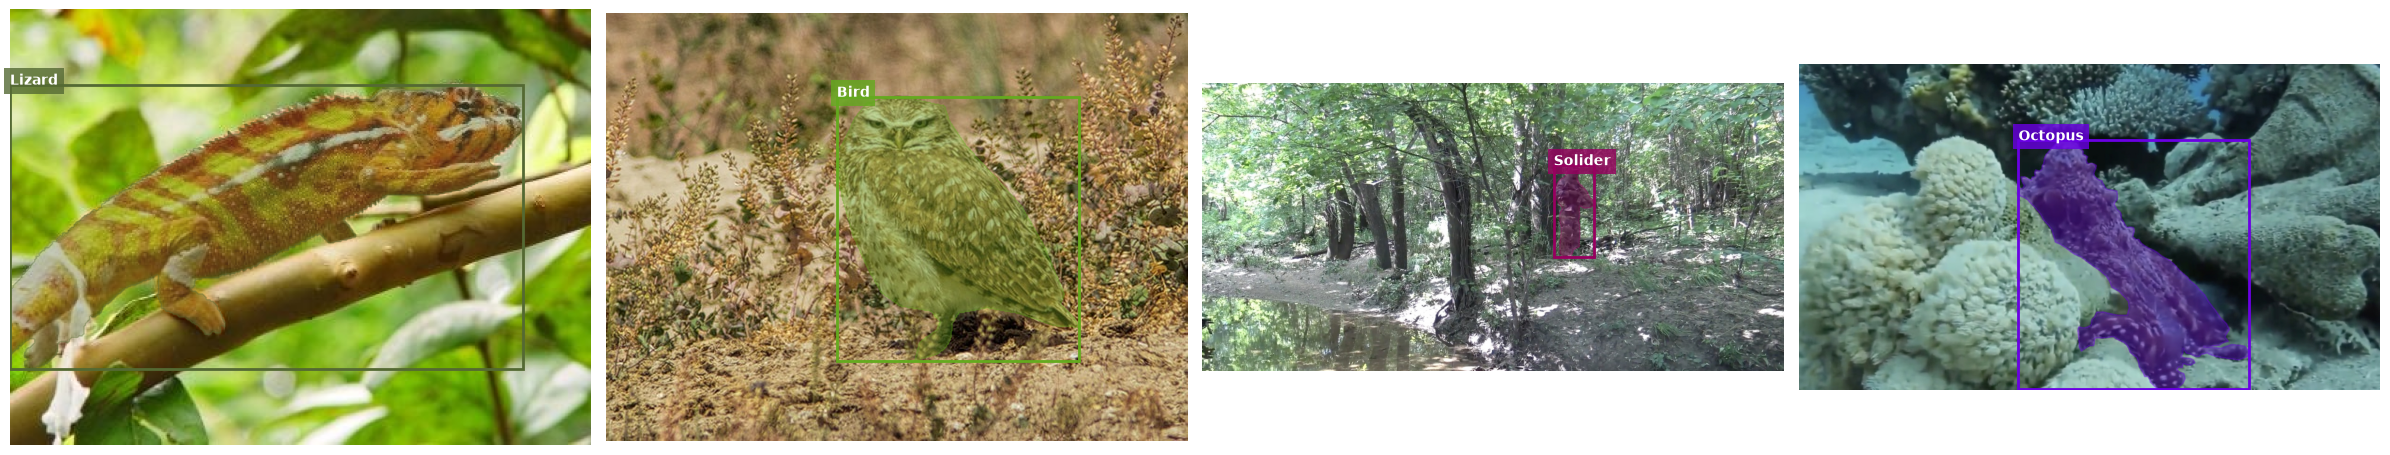

In [8]:
random.seed(2024)

with open(
    TEST_ANNOTATIONS_PATH,
    "r",
    encoding="utf-8"
) as f:
    test_annotations = json.load(f)

all_test_images = [
    os.path.join(
        IMAGES_PATH,
        image["file_name"]
    )
    for image in test_annotations["images"]
]

random_image_files = random.sample(
    all_test_images,
    4
)

display_images_with_coco_annotations(
    random_image_files,
    test_annotations,
    display_type="both"
)

## 7. VISUALIZE A FEW-SHOT CLASS

Class: Octopus
Setting: 5-shot
Images in annotation: 4
Instances in annotation: 5


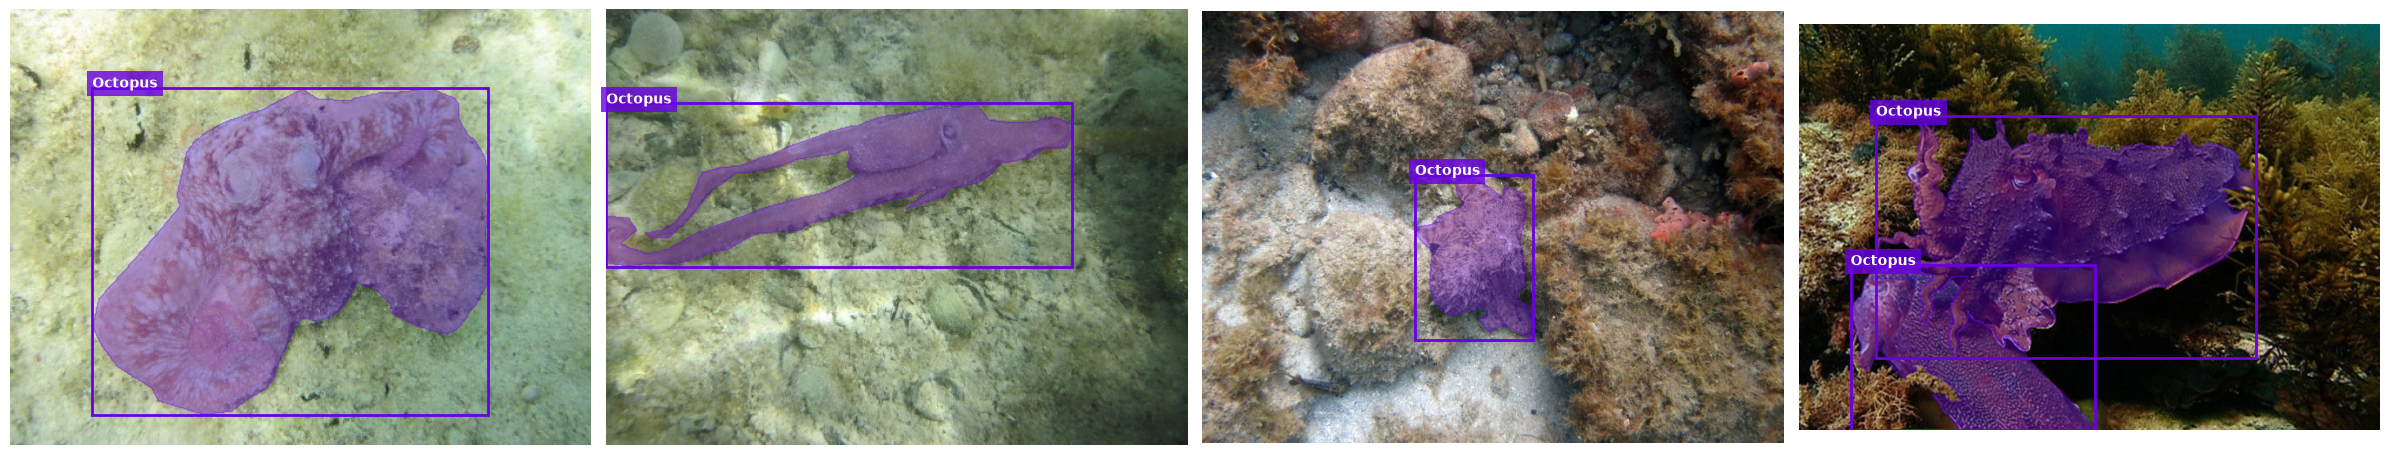

In [11]:
CLASS_NAME = "Octopus"
SHOT = 5

few_shot_file = (
    FEW_SHOT_DIR
    / f"camo5_{CLASS_NAME}_{SHOT}shot_split1.json"
)

with open(
    few_shot_file,
    "r",
    encoding="utf-8"
) as f:
    few_shot_annotations = json.load(f)

few_shot_images = [
    os.path.join(
        IMAGES_PATH,
        image["file_name"]
    )
    for image in few_shot_annotations["images"]
]

print(f"Class: {CLASS_NAME}")
print(f"Setting: {SHOT}-shot")
print(
    f"Images in annotation: "
    f"{len(few_shot_annotations['images'])}"
)
print(
    f"Instances in annotation: "
    f"{len(few_shot_annotations['annotations'])}"
)

display_images_with_coco_annotations(
    few_shot_images[:5],
    few_shot_annotations,
    display_type="both"
)

## 8. CLASS DISTRIBUTION IN TEST SET

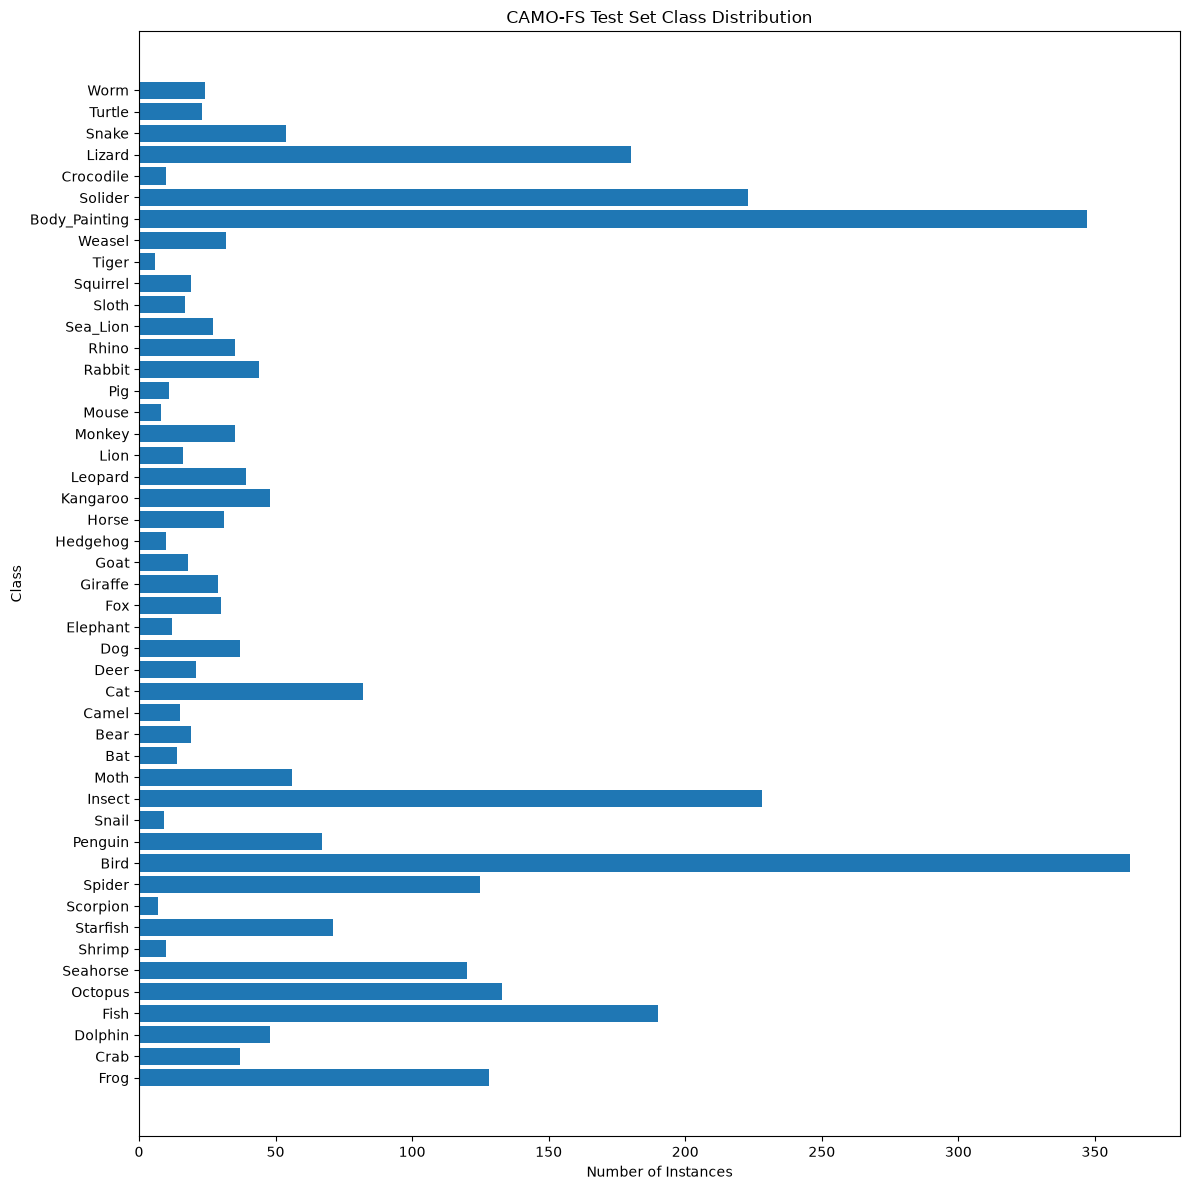

In [10]:
from collections import Counter


category_counts = Counter(
    ann["category_id"]
    for ann in test_annotations["annotations"]
)

class_names = []
instance_counts = []

for category in CAMO_CATEGORIES:

    category_id = category["id"]

    class_names.append(
        category["name"]
    )

    instance_counts.append(
        category_counts.get(
            category_id,
            0
        )
    )

plt.figure(figsize=(12, 12))

plt.barh(
    class_names,
    instance_counts
)

plt.xlabel("Number of Instances")
plt.ylabel("Class")
plt.title(
    "CAMO-FS Test Set Class Distribution"
)

plt.tight_layout()
plt.show()